Objectif

Affiner un modèle BERT pré-entraîné (par ex. bert-base-uncased) sur une tâche de classification de sentiments en utilisant un jeu de données étiqueté (par ex. IMDb, SST-2 ou votre propre jeu de données).


Instructions
1. Préparer votre environnement

Utilisez les bibliothèques Hugging Face Transformers et Datasets
Installer avec :
pip install transformers datasets

2. Charger un modèle BERT pré-entraîné

Importer un modèle et un tokenizer depuis transformers
Exemple :
from transformers import BertTokenizer, BertForSequenceClassification

3. Choisir un jeu de données

Utiliser un jeu de données annoté pour le sentiment (IMDb, SST-2 ou votre propre CSV avec colonnes texte et label)
Tokeniser le texte et préparer les entrées pour BERT
4. Affiner le modèle (Fine-Tune)

Utiliser Trainer ou une boucle d’entraînement personnalisée
Suivre la précision et la perte pour l’entraînement et la validation
Paramètres recommandés : batch size 8–16, learning rate ~2e-5
5. Évaluer les performances

Reporter la précision, le score F1 et la matrice de confusion
Optionnel : tester le modèle avec vos propres exemples d’entrée

In [ ]:
# ── NETTOYAGE AVANT UPLOAD GITHUB ──────────────────────────
import json, glob, os

# Détecte automatiquement le fichier .ipynb dans /content
notebooks = glob.glob("/content/*.ipynb")

for nb_path in notebooks:
    with open(nb_path, "r", encoding="utf-8") as f:
        nb = json.load(f)

    # Supprime metadata.widgets (cause de l'erreur GitHub)
    if "widgets" in nb.get("metadata", {}):
        del nb["metadata"]["widgets"]
        print(f"✓ 'metadata.widgets' supprimé dans : {os.path.basename(nb_path)}")
    else:
        print(f"✓ Déjà propre : {os.path.basename(nb_path)}")

    with open(nb_path, "w", encoding="utf-8") as f:
        json.dump(nb, f, indent=1, ensure_ascii=False)

print("\n✓ Notebook prêt pour GitHub — télécharge et uploade maintenant")


✓ Notebook prêt pour GitHub — télécharge et uploade maintenant


Device utilisé : cuda
GPU : Tesla T4

1. Chargement du dataset IMDb...
  Train : 2000 exemples
  Val   : 500 exemples
  Test  : 500 exemples

Exemple :
  Texte : There is no relation at all between Fortier and Profiler but the fact that both are police series ab...
  Label : 1 (positif)

2. Chargement du tokenizer bert-base-uncased...
  Tokenisation du dataset...

  Exemple de tokenisation :
  Tokens    : ['[CLS]', 'ce', 'film', 'est', 'excellent', '!', '[SEP]']
  [CLS]=101 : 101 (jeton de classification BERT)

3. Chargement du modèle BERT pré-entraîné...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

  Paramètres totaux     : 109,483,778
  Paramètres entraînables : 109,483,778
  Architecture : BERT-BASE (12 couches, 12 têtes d'attention, 768 hidden)

4. Fine-Tuning BERT (3 époques)...
   LR=2e-5 | batch=16 | max_length=128
   (environ 10-15 min sur Google Colab T4 GPU)



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.586533,0.389249,0.824000,0.822990
2,0.280152,0.379891,0.856000,0.855260
3,0.197742,0.425593,0.868000,0.867956


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✓ Entraînement terminé !
  Durée totale    : 231s
  Samples/seconde : 26.0

5. Évaluation sur le jeu de test...



  Test Accuracy : 84.80%
  Test F1 Score : 0.8478
  Test Loss     : 0.4564

6. Rapport de classification détaillé...

              precision    recall  f1-score   support

     NÉGATIF       0.90      0.80      0.84       258
     POSITIF       0.81      0.90      0.85       242

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



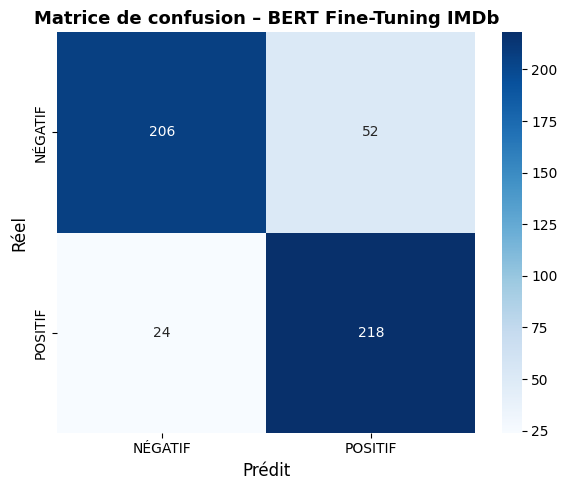

✓ matrice_confusion_bert.png sauvegardé


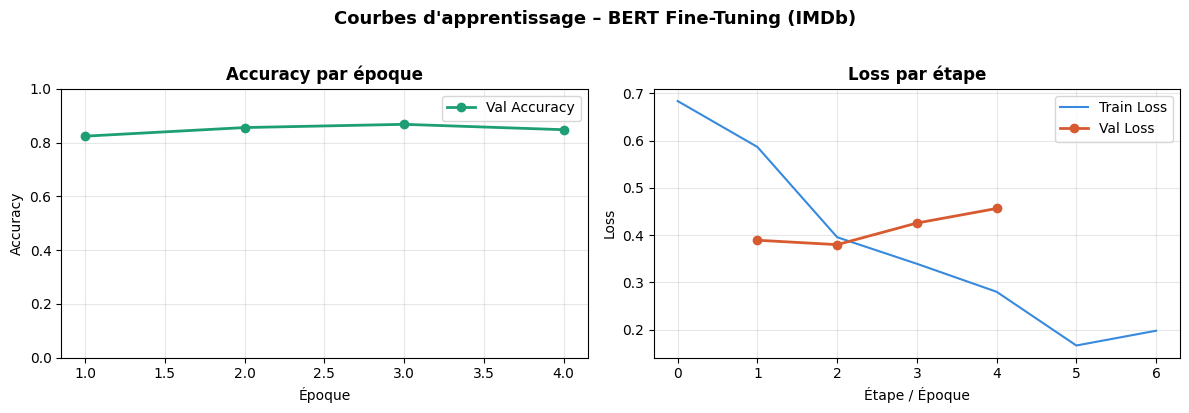

✓ courbes_bert.png sauvegardé

7. Test avec exemples personnalisés...

  Résultats de prédiction :
  Texte                                         Sentiment    Confiance
  ----------------------------------------------------------------------
  ✅ This movie was absolutely fantastic! I loved every moment of... POSITIF      98.0%
  ❌ Terrible film. Complete waste of time. I hated it. NÉGATIF      95.7%
  ❌ The acting was decent but the plot was quite boring and pred... NÉGATIF      97.5%
  ✅ One of the best movies I have ever seen in my life! POSITIF      97.8%
  ❌ Not worth watching. The story makes no sense at all. NÉGATIF      97.0%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ Modèle sauvegardé dans ./bert_imdb_finetuned

RÉCAPITULATIF – Fine-Tuning BERT (IMDb)
  Modèle de base : bert-base-uncased (110M paramètres)
  Tâche          : Classification de sentiments (2 classes)
  Dataset        : IMDb (2000 train / 500 test)
  Époques        : 3 | LR : 2e-5 | Batch : 16
  Test Accuracy  : 84.80%
  Test F1 Score  : 0.8478

LIENS AVEC LE COURS GOMYCODE :
  ✔ BERT = architecture ENCODEUR uniquement (bidirectionnel)
  ✔ Jeton [CLS] → couche de classification → softmax
  ✔ Fine-tuning = ajustement sur données étiquetées (IMDb)
  ✔ LR=2e-5 faible pour préserver poids pré-entraînés
  ✔ Bidirectionnel : contexte gauche + droit simultanément


In [ ]:
# ==============================================================================
#  CHECKPOINT : Fine-Tuning BERT pour la Classification de Sentiments
#  Modèle    : bert-base-uncased (Hugging Face)
#  Dataset   : IMDb (50 000 critiques de films – positif/négatif)
#  Framework : Hugging Face Transformers + Datasets
#  Basé sur le cours GOMYCODE – Encodeur-Décodeur et BERT
#
#  ▶ EXÉCUTION : Google Colab (GPU T4 recommandé)
#    Runtime → Change runtime type → T4 GPU
# ==============================================================================

# ─────────────────────────────────────────────
# CELLULE 1 — INSTALLATION (exécuter en premier)
# ─────────────────────────────────────────────
# !pip install transformers datasets scikit-learn -q

# ─────────────────────────────────────────────
# CELLULE 2 — IMPORTS ET CONFIGURATION
# ─────────────────────────────────────────────
import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

# Vérification GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device utilisé : {device}")
print(f"GPU : {torch.cuda.get_device_name(0) if device == 'cuda' else 'Non disponible'}")

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# ─────────────────────────────────────────────
# CELLULE 3 — CHARGEMENT DU DATASET IMDb
#  50 000 critiques de films annotées
#  label : 0 = négatif | 1 = positif
# ─────────────────────────────────────────────
print("\n1. Chargement du dataset IMDb...")
dataset = load_dataset("imdb")

# Sous-échantillonnage pour accélérer l'entraînement sur Colab
# (2000 train + 500 val + 500 test)
train_dataset = dataset["train"].shuffle(seed=42).select(range(2000))
test_full     = dataset["test"].shuffle(seed=42).select(range(1000))
val_dataset   = test_full.select(range(500))
test_dataset  = test_full.select(range(500, 1000))

print(f"  Train : {len(train_dataset)} exemples")
print(f"  Val   : {len(val_dataset)} exemples")
print(f"  Test  : {len(test_dataset)} exemples")
print(f"\nExemple :")
print(f"  Texte : {train_dataset[0]['text'][:100]}...")
print(f"  Label : {train_dataset[0]['label']} ({'positif' if train_dataset[0]['label'] == 1 else 'négatif'})")

# ─────────────────────────────────────────────
# CELLULE 4 — CHARGEMENT DU TOKENIZER BERT
#  bert-base-uncased : 12 couches, 110M paramètres
#  Selon le cours : BERT utilise une architecture
#  de codage uniquement (bidirectionnel)
# ─────────────────────────────────────────────
print("\n2. Chargement du tokenizer bert-base-uncased...")
MODEL_NAME = "bert-base-uncased"
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    """
    Tokenisation des textes pour BERT.
    - Troncature à 128 tokens (max_length) pour économiser la mémoire Colab
    - padding='max_length' pour uniformiser les séquences
    - Le jeton [CLS] en début de séquence représente la classification (cours BERT)
    """
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128,
        padding="max_length",
    )

print("  Tokenisation du dataset...")
tokenized_train = train_dataset.map(tokenize, batched=True)
tokenized_val   = val_dataset.map(tokenize, batched=True)
tokenized_test  = test_dataset.map(tokenize, batched=True)

# Supprimer la colonne texte brut et formater pour PyTorch
tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_val   = tokenized_val.remove_columns(["text"])
tokenized_test  = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_val.set_format("torch")
tokenized_test.set_format("torch")

# Vérification de la tokenisation
sample = tokenizer("Ce film est excellent !", return_tensors="pt")
print(f"\n  Exemple de tokenisation :")
print(f"  Tokens    : {tokenizer.convert_ids_to_tokens(sample['input_ids'][0][:10])}")
print(f"  [CLS]=101 : {sample['input_ids'][0][0].item()} (jeton de classification BERT)")

# ─────────────────────────────────────────────
# CELLULE 5 — CHARGEMENT DU MODÈLE BERT
#  BertForSequenceClassification :
#  BERT + couche de classification au-dessus du jeton [CLS]
#  Selon le cours : la sortie [CLS] est utilisée pour la classification
# ─────────────────────────────────────────────
print("\n3. Chargement du modèle BERT pré-entraîné...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,                    # 2 classes : positif / négatif
    id2label={0: "NÉGATIF", 1: "POSITIF"},
    label2id={"NÉGATIF": 0, "POSITIF": 1},
)
model = model.to(device)

# Statistiques du modèle
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Paramètres totaux     : {total_params:,}")
print(f"  Paramètres entraînables : {trainable_params:,}")
print(f"  Architecture : BERT-BASE (12 couches, 12 têtes d'attention, 768 hidden)")

# ─────────────────────────────────────────────
# CELLULE 6 — MÉTRIQUES D'ÉVALUATION
# ─────────────────────────────────────────────
def compute_metrics(eval_pred):
    """
    Calcul des métriques : Accuracy + F1
    Selon le cours NLP : précision, rappel, F1
    """
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average="weighted")
    return {"accuracy": acc, "f1": f1}

# ─────────────────────────────────────────────
# CELLULE 7 — CONFIGURATION DE L'ENTRAÎNEMENT
#  Paramètres recommandés par le checkpoint :
#  batch_size=8-16, learning_rate=2e-5
# ─────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./bert_sentiment_results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",        # ← corrigé (était evaluation_strategy)
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_dir="./logs",
    logging_steps=50,
    fp16=True if device == "cuda" else False,
    report_to="none",
)

# ─────────────────────────────────────────────
# CELLULE 8 — ENTRAÎNEMENT (FINE-TUNING)
#  Selon le cours BERT :
#  Phase 1 : BERT pré-entraîné (MLM + NSP sur grands corpus)
#  Phase 2 : Fine-tuning sur données étiquetées (ici IMDb)
# ─────────────────────────────────────────────
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    processing_class=tokenizer,      # ← remplace 'tokenizer'
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\n4. Fine-Tuning BERT (3 époques)...")
print("   LR=2e-5 | batch=16 | max_length=128")
print("   (environ 10-15 min sur Google Colab T4 GPU)\n")

train_result = trainer.train()

print(f"\n✓ Entraînement terminé !")
print(f"  Durée totale    : {train_result.metrics['train_runtime']:.0f}s")
print(f"  Samples/seconde : {train_result.metrics['train_samples_per_second']:.1f}")

# ─────────────────────────────────────────────
# CELLULE 9 — ÉVALUATION SUR LE JEU DE TEST
# ─────────────────────────────────────────────
print("\n5. Évaluation sur le jeu de test...")
test_results = trainer.evaluate(tokenized_test)

print(f"\n  Test Accuracy : {test_results['eval_accuracy']*100:.2f}%")
print(f"  Test F1 Score : {test_results['eval_f1']:.4f}")
print(f"  Test Loss     : {test_results['eval_loss']:.4f}")

# ─────────────────────────────────────────────
# CELLULE 10 — RAPPORT DE CLASSIFICATION COMPLET
# ─────────────────────────────────────────────
print("\n6. Rapport de classification détaillé...")

# Prédictions sur le test
predictions_output = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions_output.predictions, axis=-1)
y_true = predictions_output.label_ids

print("\n" + classification_report(
    y_true, y_pred,
    target_names=["NÉGATIF", "POSITIF"]
))

# ─────────────────────────────────────────────
# CELLULE 11 — MATRICE DE CONFUSION
# ─────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=["NÉGATIF", "POSITIF"],
    yticklabels=["NÉGATIF", "POSITIF"],
    ax=ax
)
ax.set_xlabel('Prédit', fontsize=12)
ax.set_ylabel('Réel', fontsize=12)
ax.set_title('Matrice de confusion – BERT Fine-Tuning IMDb', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matrice_confusion_bert.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ matrice_confusion_bert.png sauvegardé")

# ─────────────────────────────────────────────
# CELLULE 12 — COURBES D'APPRENTISSAGE
# ─────────────────────────────────────────────
logs = trainer.state.log_history

train_loss = [x['loss']         for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_acc   = [x['eval_accuracy'] for x in logs if 'eval_accuracy' in x]
eval_loss  = [x['eval_loss']     for x in logs if 'eval_loss' in x]
epochs     = list(range(1, len(eval_acc) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, eval_acc,  'o-', color='#1D9E75', linewidth=2, label='Val Accuracy')
axes[0].set_title('Accuracy par époque', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(len(train_loss)), train_loss, color='#378ADD', linewidth=1.5, label='Train Loss')
axes[1].plot(epochs, eval_loss, 'o-', color='#D85A30', linewidth=2, label='Val Loss')
axes[1].set_title('Loss par étape', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Étape / Époque')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage – BERT Fine-Tuning (IMDb)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('courbes_bert.png', dpi=100, bbox_inches='tight')
plt.show()
print("✓ courbes_bert.png sauvegardé")

# ─────────────────────────────────────────────
# CELLULE 13 — TEST AVEC VOS PROPRES EXEMPLES
#  Selon le cours : BERT analyse le contexte
#  de manière bidirectionnelle (gauche + droite)
# ─────────────────────────────────────────────
print("\n7. Test avec exemples personnalisés...")

def predict_sentiment(texts, model, tokenizer, device):
    """Prédit le sentiment de textes personnalisés."""
    model.eval()
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs       = torch.softmax(outputs.logits, dim=-1)
    predictions = torch.argmax(probs, dim=-1)
    labels      = ["NÉGATIF", "POSITIF"]

    results = []
    for text, pred, prob in zip(texts, predictions, probs):
        results.append({
            "texte"      : text[:60] + "..." if len(text) > 60 else text,
            "sentiment"  : labels[pred.item()],
            "confiance"  : f"{prob[pred.item()].item()*100:.1f}%"
        })
    return results

exemples = [
    "This movie was absolutely fantastic! I loved every moment of it.",
    "Terrible film. Complete waste of time. I hated it.",
    "The acting was decent but the plot was quite boring and predictable.",
    "One of the best movies I have ever seen in my life!",
    "Not worth watching. The story makes no sense at all.",
]

print("\n  Résultats de prédiction :")
print(f"  {'Texte':<45} {'Sentiment':<12} {'Confiance'}")
print("  " + "-"*70)

results = predict_sentiment(exemples, model, tokenizer, device)
for r in results:
    emoji = "✅" if r['sentiment'] == "POSITIF" else "❌"
    print(f"  {emoji} {r['texte']:<43} {r['sentiment']:<12} {r['confiance']}")

# ─────────────────────────────────────────────
# CELLULE 14 — SAUVEGARDE DU MODÈLE
# ─────────────────────────────────────────────
model.save_pretrained("./bert_imdb_finetuned")
tokenizer.save_pretrained("./bert_imdb_finetuned")
print("\n✓ Modèle sauvegardé dans ./bert_imdb_finetuned")

# ─────────────────────────────────────────────
# RÉCAPITULATIF FINAL
# ─────────────────────────────────────────────
print("\n" + "="*60)
print("RÉCAPITULATIF – Fine-Tuning BERT (IMDb)")
print("="*60)
print(f"  Modèle de base : bert-base-uncased (110M paramètres)")
print(f"  Tâche          : Classification de sentiments (2 classes)")
print(f"  Dataset        : IMDb ({len(train_dataset)} train / {len(test_dataset)} test)")
print(f"  Époques        : 3 | LR : 2e-5 | Batch : 16")
print(f"  Test Accuracy  : {test_results['eval_accuracy']*100:.2f}%")
print(f"  Test F1 Score  : {test_results['eval_f1']:.4f}")
print()
print("LIENS AVEC LE COURS GOMYCODE :")
print("  ✔ BERT = architecture ENCODEUR uniquement (bidirectionnel)")
print("  ✔ Jeton [CLS] → couche de classification → softmax")
print("  ✔ Fine-tuning = ajustement sur données étiquetées (IMDb)")
print("  ✔ LR=2e-5 faible pour préserver poids pré-entraînés")
print("  ✔ Bidirectionnel : contexte gauche + droit simultanément")
print("="*60)
